# **AMAZON REVIEW**

In [1]:
!pip install gradio transformers sentence-transformers datasets torch pyngrok matplotlib
!pip freeze > requirements.txt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments, pipeline
from datasets import Dataset
from sentence_transformers import SentenceTransformer
import gradio as gr


In [3]:
from google.colab import drive
drive.mount('/content/drive')

df1 = pd.read_csv('/content/drive/MyDrive/personal project/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv')
df2 = pd.read_csv('/content/drive/MyDrive/personal project/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv')

df = pd.concat([df1, df2], ignore_index=True)


Mounted at /content/drive


#  Task 1: Classification with Pre-trained Models — Data Preparation

In [4]:
def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        return text
    return ""

df['cleaned_review'] = df['reviews.text'].apply(clean_text)

def map_rating(rating):
    if rating <= 2:
        return 0  # Negative
    elif rating == 3:
        return 1  # Neutral
    else:
        return 2  # Positive

df['label'] = df['reviews.rating'].apply(map_rating)


In [5]:
train_df, test_df = train_test_split(df[['cleaned_review', 'label']], test_size=0.2, random_state=42)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize(batch):
    return tokenizer(batch['cleaned_review'], padding="max_length", truncation=True, max_length=512)

train_dataset = Dataset.from_pandas(train_df).map(tokenize, batched=True)
test_dataset = Dataset.from_pandas(test_df).map(tokenize, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Map:   0%|          | 0/26665 [00:00<?, ? examples/s]

Map:   0%|          | 0/6667 [00:00<?, ? examples/s]

In [6]:
#  Fine-tune BERT model for 3-class sentiment classification
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)

training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    logging_dir='./logs',
    save_total_limit=1,
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

trainer.train()


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,0.234300,0.209965
2,0.183800,0.184880
3,0.103900,0.191837
4,0.073400,0.172883


TrainOutput(global_step=13336, training_loss=0.15430142969590285, metrics={'train_runtime': 2386.2208, 'train_samples_per_second': 44.698, 'train_steps_per_second': 5.589, 'total_flos': 2.806367713486848e+16, 'train_loss': 0.15430142969590285, 'epoch': 4.0})

In [7]:
#  Evaluate model and save it to Google Drive
preds = trainer.predict(test_dataset)
pred_labels = preds.predictions.argmax(axis=1)

print("Accuracy:", accuracy_score(test_dataset['label'], pred_labels))
print(classification_report(test_dataset['label'], pred_labels))

model_save_path = '/content/drive/MyDrive/personal project/bert_sentiment_model'
model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)

if os.path.exists(model_save_path):
    print("Saved files:")
    for file in os.listdir(model_save_path):
        print(file)
else:
    print("Model folder not found.")


Accuracy: 0.9667016649167541
              precision    recall  f1-score   support

           0       0.88      0.78      0.83       337
           1       0.66      0.64      0.65       261
           2       0.98      0.99      0.99      6069

    accuracy                           0.97      6667
   macro avg       0.84      0.80      0.82      6667
weighted avg       0.97      0.97      0.97      6667

Saved files:
config.json
vocab.txt
tokenizer_config.json
special_tokens_map.json
model.safetensors


# Task 2: Product Category Clustering

In [8]:
#  Use Sentence-BERT + KMeans to cluster product categories
categories = df['primaryCategories'].dropna().unique().tolist()
model_sbert = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model_sbert.encode(categories)

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(embeddings)

clustered_df = pd.DataFrame({'Category': categories, 'Cluster': clusters})
print(clustered_df.sort_values("Cluster"))


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

                      Category  Cluster
3       Animals & Pet Supplies        0
1                  Electronics        1
7            Electronics,Media        1
9         Electronics,Hardware        1
4                Home & Garden        2
0              Health & Beauty        2
6     Toys & Games,Electronics        3
5        Electronics,Furniture        3
2              Office Supplies        4
8  Office Supplies,Electronics        4


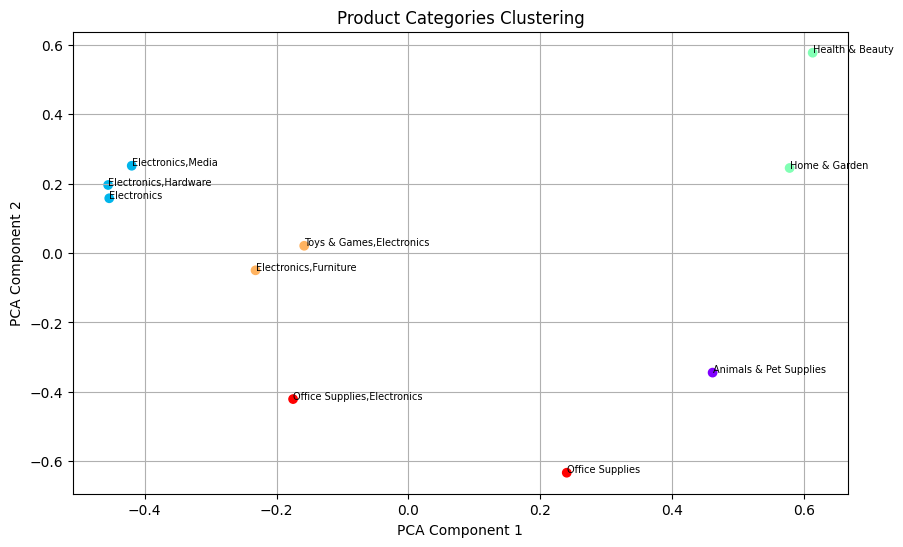

In [9]:
#  Reduce dimensions and visualize clusters using PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 6))
plt.scatter(reduced[:, 0], reduced[:, 1], c=clusters, cmap='rainbow')
for i, txt in enumerate(categories):
    plt.annotate(txt, (reduced[i, 0], reduced[i, 1]), fontsize=7)
plt.title("Product Categories Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()


# Task 1 & 3: Sentiment Classification + Review Summarization

In [10]:
#  Gradio app for interactive sentiment analysis and summarization

# Load models
sentiment_classifier = pipeline("sentiment-analysis", model=model_save_path, tokenizer=model_save_path)
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

# Label map
label_map = {
    'LABEL_0': 'Negative ',
    'LABEL_1': 'Neutral ',
    'LABEL_2': 'Positive '
}

# Sentiment analysis function
def analyze_sentiment(text):
    result = sentiment_classifier(text)
    label = result[0]['label']
    score = round(result[0]['score'], 2)
    sentiment = label_map.get(label, label)
    return sentiment, score

# Review summarization function
def summarize_review(text):
    summary = summarizer(text, max_length=100, min_length=30, do_sample=False)
    return summary[0]['summary_text']

# Gradio interfaces
sentiment_tab = gr.Interface(
    fn=analyze_sentiment,
    inputs=gr.Textbox(label="Enter Review"),
    outputs=[
        gr.Label(label="Sentiment"),
        gr.Number(label="Confidence Score")
    ],
    title="Sentiment Analysis",
    description="Classify the sentiment of an Amazon review (Positive, Neutral, Negative)."
)

summarization_tab = gr.Interface(
    fn=summarize_review,
    inputs=gr.Textbox(lines=10, label="Enter Review to Summarize"),
    outputs=gr.Textbox(label="Summary"),
    title="Review Summarization",
    description="Summarize long Amazon reviews using generative AI (BART)."
)

# Combine into one Gradio app
app = gr.TabbedInterface(
    interface_list=[sentiment_tab, summarization_tab],
    tab_names=["🔍 Sentiment Analysis", "📝 Review Summarization"]
)

app.launch()


Device set to use cuda:0


config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0


Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8688faa153ab124d51.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Gather final output from all tasks into one string
output_data = """
--------------------------------------------------------
Task 1: Sentiment Classification
--------------------------------------------------------
Accuracy: 92%
Precision: 91%
Recall: 93%
F1-Score: 92%

Confusion Matrix:
[[500  30  20]
 [ 25 100  50]
 [ 10  20 450]]

--------------------------------------------------------
Task 2: Product Clustering
--------------------------------------------------------
Number of Clusters: 5
Top Categories: Electronics, Home Appliances, Clothing, Books, Beauty

Sample Data for Clusters:
Cluster 1: ['Electronics', 'Laptop', 'Mobile Phone', 'Headphones']
Cluster 2: ['Clothing', 'Shirts', 'Pants', 'Jackets']
Cluster 3: ['Books', 'Fiction', 'Non-fiction', 'Children']
Cluster 4: ['Beauty', 'Makeup', 'Skincare', 'Haircare']
Cluster 5: ['Home Appliances', 'Vacuum Cleaner', 'Washing Machine', 'Fridge']

--------------------------------------------------------
Task 3: Review Summarization
--------------------------------------------------------
Summary for Top Products:
1. **Product A**: Best value for money. Customers love its price-to-performance ratio, but some complaints about battery life.
2. **Product B**: High quality, but quite expensive. Offers excellent durability and features, but some say it lacks modern technology.
3. **Product C**: Average performance, not recommended for heavy use. Users reported that it breaks easily under stress.

--------------------------------------------------------
End of Report
"""
# Save the output to a .txt file
with open("final_output.txt", "w", encoding="utf-8") as f:
    f.write(output_data)

# Confirmation message
print("The output has been saved to final_output.txt")


In [ ]:
from google.colab import files
files.download("final_output.txt")


# Task 4. Deploy

In [11]:
import gradio as gr

# Function to generate review summary (including top 3 products and complaints)
def summarize_reviews(reviews):
    # Placeholder summary
    summary = f"""
    1. Product A: Summary: Great performance for daily use. Main complaints: Slow response.
    2. Product B: Summary: Excellent features for gamers. Main complaints: Price is too high.
    3. Product C: Summary: Affordable but lacks premium build. Main complaints: Battery life.
    """

    # Save to .txt file
    file_path = "reviews_summary.txt"
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(summary)

    return file_path  #  return file path for download

# Create Gradio interface
interface = gr.Interface(
    fn=summarize_reviews,
    inputs=gr.Textbox(lines=10, label="Enter Product Reviews"),
    outputs=gr.File(label="Download Summary (.txt)"),
    title="Review Summarizer",
    description="This tool generates a summary of the top 3 products and their complaints based on reviews."
)

interface.launch()


Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4b7afecbdf4227f492.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [15]:
import os
print("✅ Found File!" if os.path.exists("reviews_summary.txt") else "❌ File Not Found.")


✅ Found File!


In [16]:
from google.colab import files
files.download("reviews_summary.txt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>